# ---------------Intro to data visualisations-----------------

# Part2 

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
path = r'C:\Users\bouas\instacart bascket analysis'
intro_to_data_410 = pd.read_pickle(os.path.join(path, 'data', 'prepared_data', 'intro_to_data_410.pkl'))

In [3]:
df= intro_to_data_410

In [4]:
df.columns

Index(['user_id', 'gender', 'STATE', 'age', 'date_joined',
       'household_dependents', 'familiar_status', 'income', 'Unnamed: 0',
       'product_id', 'product_name', 'aisle_id', 'department_id', 'prices',
       'order_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'add_to_cart_order',
       'reordered', 'price_range_loc', 'Busiest day', 'Busiest days',
       'busiest_period_of_day', 'max_order', 'loyalty_flag', 'mean_price',
       'spending_flag', 'median_days_since_last_orders',
       'order_frequency_flag', '_merge'],
      dtype='object')

# 3/You need to provide the Instacart senior stakeholders with descriptive findings about sales. Create a histogram of the “order_hour_of_day” column.

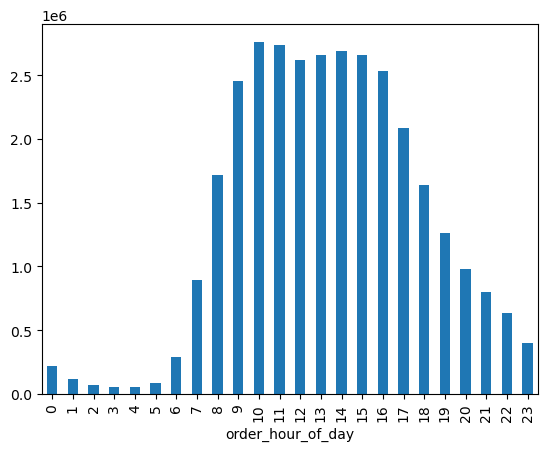

In [5]:
bar = df['order_hour_of_day'].value_counts().sort_index().plot.bar()

In [6]:
bar.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'order_hour_of_day.png'))

### analysing bar chart

### The histogram show us the busiest  hour of a day , It shows how the pace increases more and more each day from 7 a.m. to 6 p.m., with the busiest hour at 10 a.m., as we did in the previous exercise.

# 4/The marketing team is curious about the distribution of orders among customers in terms of loyalty. Create a bar chart from the “loyalty_flag” column.

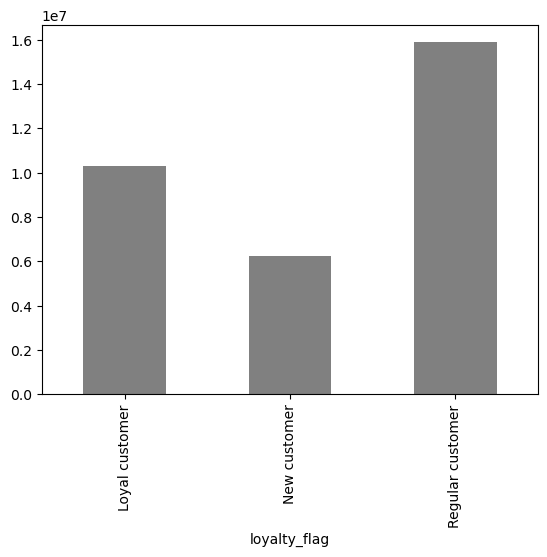

In [10]:
bar2 = df['loyalty_flag'].value_counts().sort_index().plot.bar(color =['gray'])

### >>>>Regular customers have the highest number of orders.

# 5/Check whether there’s a difference in expenditure (the “prices” column) depending on the hour of the day. 

##### creating random seed

In [11]:
np.random.seed(4)
dev = np.random.rand(len(df)) <= 0.7

##### creating a list of holding True/False values 

In [12]:
dev

array([False,  True, False, ...,  True,  True,  True], shape=(32406041,))

##### creating sample part 70/30

In [16]:
big = df[dev]
small = df[~dev]

##### Imputing variable : order hour of the day and prices 

In [17]:
df_S = small[['order_hour_of_day','prices']]

##### Checking rows count

In [20]:
df_S

,order_hour_of_day,prices
0,15,9.0
2,15,9.0
3,9,4.3
6,11,4.3
10,9,4.0
...,...,...
32406021,19,6.5
32406027,11,4.5
32406032,16,1.2
32406033,16,1.2


#### displaying df count to check the sample count

In [21]:
df

,user_id,gender,STATE,age,date_joined,household_dependents,familiar_status,income,Unnamed: 0,product_id,...,Busiest day,Busiest days,busiest_period_of_day,max_order,loyalty_flag,mean_price,spending_flag,median_days_since_last_orders,order_frequency_flag,_merge
0,26711,Female,Missouri,48,1/1/2017,3,married,165665,195,196,...,Regularly busy,Regularly busy,Most orders,8,New customer,7.988889,Low spender,19.0,Regular customer,both
1,26711,Female,Missouri,48,1/1/2017,3,married,165665,195,196,...,Regularly busy,Busiest days,Most orders,8,New customer,7.988889,Low spender,19.0,Regular customer,both
2,26711,Female,Missouri,48,1/1/2017,3,married,165665,195,196,...,Regularly busy,Busiest days,Most orders,8,New customer,7.988889,Low spender,19.0,Regular customer,both
3,26711,Female,Missouri,48,1/1/2017,3,married,165665,6184,6184,...,Regularly busy,Regularly busy,Most orders,8,New customer,7.988889,Low spender,19.0,Regular customer,both
4,26711,Female,Missouri,48,1/1/2017,3,married,165665,6184,6184,...,Regularly busy,Regularly busy,Most orders,8,New customer,7.988889,Low spender,19.0,Regular customer,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32406036,80148,Female,New York,55,4/1/2020,1,married,57095,38754,38750,...,Regularly busy,Regularly busy,Most orders,4,New customer,3.886667,Low spender,12.0,Regular customer,both
32406037,80148,Female,New York,55,4/1/2020,1,married,57095,39073,39069,...,Regularly busy,Regularly busy,Most orders,4,New customer,3.886667,Low spender,12.0,Regular customer,both
32406038,80148,Female,New York,55,4/1/2020,1,married,57095,39976,39972,...,Regularly busy,Regularly busy,Most orders,4,New customer,3.886667,Low spender,12.0,Regular customer,both
32406039,80148,Female,New York,55,4/1/2020,1,married,57095,41431,41427,...,Regularly busy,Regularly busy,Most orders,4,New customer,3.886667,Low spender,12.0,Regular customer,both


#### >>>The sample has 9721457, which shows that we are indeed at 30% of the total of df
#### 32406041*0,3 =9,721,812.3 witch is pratically the same 
#### we can alsoo do this with len(big) + len(small)

#### displaying chart

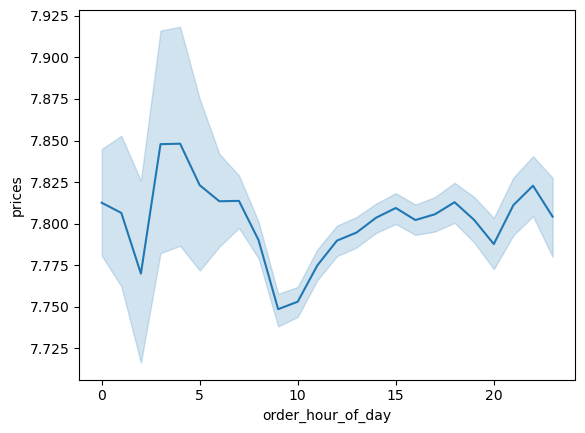

In [18]:
line = sns.lineplot(data=df_S, x='order_hour_of_day', y='prices')

### second check of results

#### *Due to insufficient memory, the PC freezes and restarts. I wrote the verification code for Big; it should be the same for the Big sample.

##### df_G= big[['order_hour_of_day','prices']]
##### line2 = sns.lineplot(data=df_G, x='order_hour_of_day', y='prices')

# 6/Now that you have information about customers, you need to conduct some exploratory analysis of customer demographics to inform the targeted marketing campaigns

In [25]:
df_S1 = small[['age','household_dependents']]

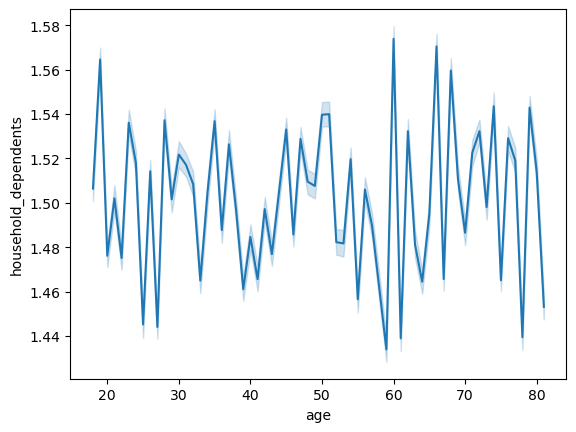

In [26]:
line1 = sns.lineplot(data=df_S1, x='age', y='household_dependents')

### The chart shows us a constant volatility throughout the ages of consumers in relation to the people who depend on them; this shows that there is no strong relationship between the age of consumers and the number of people who are dependent on them, but what we can deduce, and most importantly, is that generally consumers have between 1 and 2 dependents (partner or children or other).

# 7/You’ll also need to explore whether there’s a connection between age and spending power (income). 

In [27]:
df_S2 = small[['age','income']]

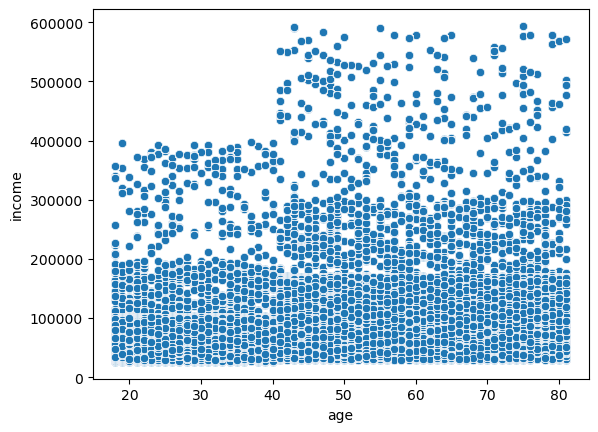

In [28]:
scatterplot = sns.scatterplot(data = df_S2, x = 'age', y = 'income')

### According to this scatterplot, we can say that there is no linear correlation between age and income , income is not dependent on age. However  we observe a non-linear trend where high incomes appear more frequently from the age of 45. we can dig deeper and deduce that:

#### *With age, people's wealth increases more and more significantly.
#### *The majority of people have incomes between 0 and 200,000, regardless of age.
#### *There is a category of people with higher incomes, extending up to 400,000, regardless of age, but the majority of this category is 45 years of age or older. This is deduced from the fact that we see a greater concentration of points in the middle to the right (from age 45 onwards).
#### *This category of people is less significant than the majority of people mentioned at the beginning.
#### *The last category is the rarest, for people with incomes approaching 600,000. Their age starts at 40, and the majority of them have An age of over 60.
#### *This last category does not exist for those under 40.

In [29]:
# exporting visualisations
scatterplot.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'scatterplot.png'))
line1.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'line_chart_household_dependents.png'))
line.figure.savefig(os.path.join(path, 'data', 'prepared_data', 'line_chart_price_ohd.png'))